In [1]:
import pandas as pd

In [3]:
df=pd.read_csv(r"C:\Users\ishit\OneDrive\Desktop\ML-CHURN-PROJECT\Churn_prediction\customer_churn_data.csv")

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [7]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [9]:
df["InternetService"]=df["InternetService"].fillna("")

In [10]:
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [24]:
numeric_columns_data=df.select_dtypes(include=["number"])

In [27]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


Business Insights
1. Tenure strongly determines TotalCharges.
2. MonthlyCharges moderately affects TotalCharges.
3. Age has little linear relationship with billing variables.
4. CustomerID is irrelevant.

In [28]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,,4465.56,No,Yes


In [39]:
import matplotlib.pyplot as plt

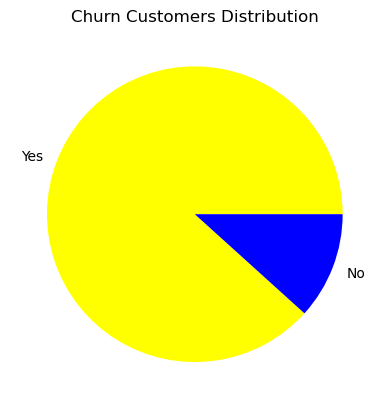

In [43]:
df["Churn"].value_counts().plot(kind="pie",colors=["yellow","blue"])
plt.title("Churn Customers Distribution")
plt.ylabel("")
plt.show()


In [45]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

1. This suggests that customers who left were paying more on average.
2. Customers with higher monthly charges appear more likely to leave.

In [46]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

Customers who leave are paying significantly more on average.
Higher monthly charges appear to be associated with a greater likelihood of churn.
The company should pay special attention to customers with high monthly charges, especially:
1. Male customers paying ₹75+ per month
2. Any customer whose charges are significantly above average


In [47]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

1. Average tenure ≈ 30.26 months
2. These customers have stayed with the company for about 2.5 years on average.
3. Average tenure ≈ 17.48 months
4. These customers left after about 1.5 years on average.

This suggests:

Newer customers are more likely to leave.
Retaining customers during the first year or two is especially important.


In [48]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

This suggests that age has a very weak relationship with churn.

The difference of just 1.34 years is small, so age alone is unlikely to be a strong predictor of whether a customer will leave.

In [49]:
df.head(1)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes


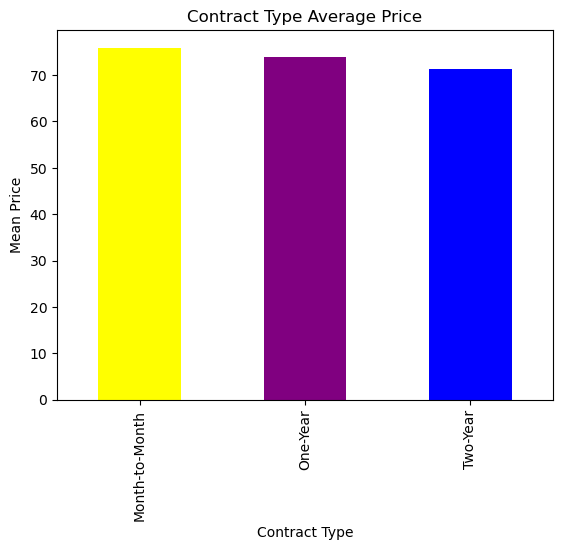

In [55]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar",color=["yellow","purple","blue"])
plt.title("Contract Type Average Price")
plt.xlabel("Contract Type")
plt.ylabel("Mean Price")
plt.show()


1. Customers paying higher monthly charges and having no long-term      commitment   are more likely to leave.
Thus, Month-to-Month customers are often the highest-risk group.
2. This suggests that customers who commit to longer contracts receive better pricing or discounts.

(array([48., 57., 41., 53., 53., 52., 53., 55., 50., 43., 36., 68., 46.,
        68., 36., 45., 66., 42., 44., 44.]),
 array([ 30.   ,  34.498,  38.996,  43.494,  47.992,  52.49 ,  56.988,
         61.486,  65.984,  70.482,  74.98 ,  79.478,  83.976,  88.474,
         92.972,  97.47 , 101.968, 106.466, 110.964, 115.462, 119.96 ]),
 <BarContainer object of 20 artists>)

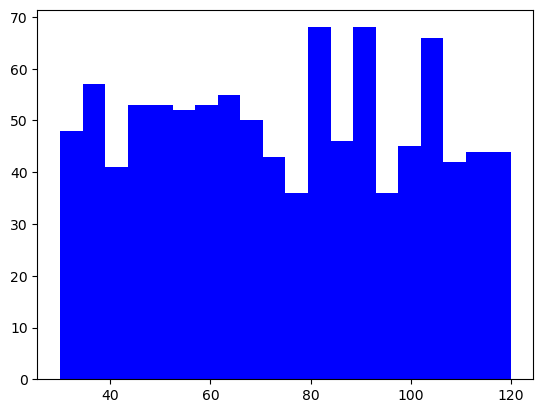

In [57]:
plt.hist(df["MonthlyCharges"],bins=20,color="blue")